In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy

In [143]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/owid-covid-data.csv')
data.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-02-24,5.0,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,37.746,0.5,64.83,0.511,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-02-25,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,37.746,0.5,64.83,0.511,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-02-26,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,37.746,0.5,64.83,0.511,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-02-27,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,37.746,0.5,64.83,0.511,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-02-28,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,37.746,0.5,64.83,0.511,NaN,NaN,NaN,NaN


In [144]:
selecred_columns = ['iso_code','location','date','total_cases','population']
new_data = data[selecred_columns]
new_data

,iso_code,location,date,total_cases,population
0,AFG,Afghanistan,2020-02-24,5.0,39835428.0
1,AFG,Afghanistan,2020-02-25,5.0,39835428.0
2,AFG,Afghanistan,2020-02-26,5.0,39835428.0
3,AFG,Afghanistan,2020-02-27,5.0,39835428.0
4,AFG,Afghanistan,2020-02-28,5.0,39835428.0
...,...,...,...,...,...
192296,ZWE,Zimbabwe,2022-06-03,253236.0,15092171.0
192297,ZWE,Zimbabwe,2022-06-04,253236.0,15092171.0
192298,ZWE,Zimbabwe,2022-06-05,253338.0,15092171.0
192299,ZWE,Zimbabwe,2022-06-06,253508.0,15092171.0


In [145]:
location = new_data['location']
location

,location
0,Afghanistan
1,Afghanistan
2,Afghanistan
3,Afghanistan
4,Afghanistan
...,...
192296,Zimbabwe
192297,Zimbabwe
192298,Zimbabwe
192299,Zimbabwe


In [146]:
location.unique()

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Asia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bonaire Sint Eustatius and Saba',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Cayman Islands', 'Central African Republic', 'Chad', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao',
       'Cyprus', 'Czechia', 'Democratic Republic of Congo', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethi

In [147]:
kor_df = new_data[new_data.location=='South Korea']
kor_df = kor_df.set_index('date')
kor_df = kor_df['total_cases']
kor_df.head()

,total_cases
date,
2020-01-22,1.0
2020-01-23,1.0
2020-01-24,2.0
2020-01-25,2.0
2020-01-26,3.0


In [101]:
us_df = new_data[new_data.location=='United States']
us_df = us_df.set_index('date')
us_df = us_df['total_cases']
us_df.head()

,total_cases
date,
2020-01-22,1.0
2020-01-23,1.0
2020-01-24,2.0
2020-01-25,2.0
2020-01-26,5.0


In [102]:
kor_df.index

Index(['2020-01-22', '2020-01-23', '2020-01-24', '2020-01-25', '2020-01-26',
       '2020-01-27', '2020-01-28', '2020-01-29', '2020-01-30', '2020-01-31',
       ...
       '2022-05-29', '2022-05-30', '2022-05-31', '2022-06-01', '2022-06-02',
       '2022-06-03', '2022-06-04', '2022-06-05', '2022-06-06', '2022-06-07'],
      dtype='object', name='date', length=868)

In [103]:
final_df = pd.DataFrame({'KOR': kor_df, 'USA' : us_df }, index=kor_df.index)
final_df.head()

,KOR,USA
date,,
2020-01-22,1.0,1.0
2020-01-23,1.0,1.0
2020-01-24,2.0,2.0
2020-01-25,2.0,2.0
2020-01-26,3.0,5.0


<Axes: xlabel='date'>

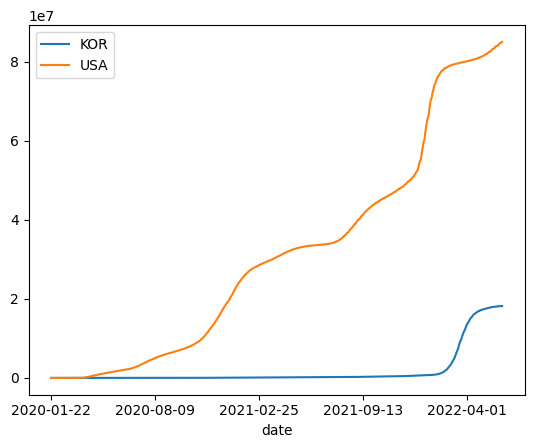

In [104]:
final_df.plot.line()

In [105]:
# 대한민국의 인구
kor_df = new_data[new_data.location=='South Korea']
kor_df = kor_df.set_index('date')
kor_population = kor_df['population']['2020-01-22']
print(kor_population)

# 미국의 인구
us_df = new_data[new_data.location=='United States']
us_df = us_df.set_index('date')
us_population = us_df['population']['2020-01-22']
print(us_population)

51305184.0
332915074.0


In [106]:
# 인구 비율 구하기
# 미국 인구를 대한민국 인구로 나누어 비율을 확인

rate = round((us_population/kor_population), 2)
rate

np.float64(6.49)

In [107]:
final_df = pd.DataFrame({'KOR': final_df['KOR']*rate, 'USA' : final_df['USA'] }, index=kor_df.index)
final_df.head()

,KOR,USA
date,,
2020-01-22,6.49,1.0
2020-01-23,6.49,1.0
2020-01-24,12.98,2.0
2020-01-25,12.98,2.0
2020-01-26,19.47,5.0


<Axes: xlabel='date'>

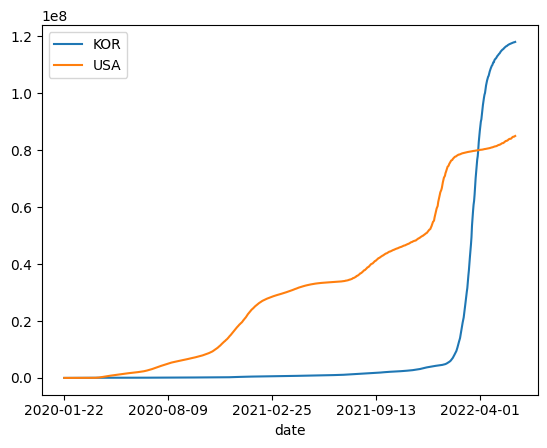

In [108]:
final_df.plot.line()

<Axes: xlabel='date'>

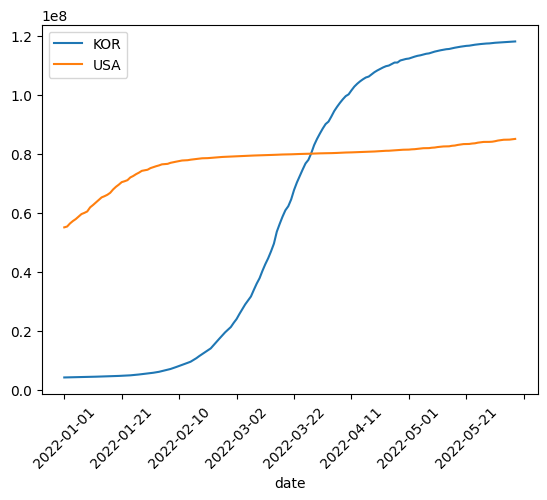

In [114]:
final_df['2022-01-01': ].plot.line(rot=45)

프랑스와 비교

In [148]:
fr_df = new_data[new_data.location=='France']
fr_df.head()

,total_cases
date,
2020-01-24,2.0
2020-01-25,3.0
2020-01-26,3.0
2020-01-27,3.0
2020-01-28,4.0


In [169]:
kor_df = new_data[new_data.location=='South Korea']
kor_df.head()

,iso_code,location,date,total_cases,population
160818,KOR,South Korea,2020-01-22,1.0,51305184.0
160819,KOR,South Korea,2020-01-23,1.0,51305184.0
160820,KOR,South Korea,2020-01-24,2.0,51305184.0
160821,KOR,South Korea,2020-01-25,2.0,51305184.0
160822,KOR,South Korea,2020-01-26,3.0,51305184.0


In [165]:
fr_date_index_df = fr_df.set_index('date')
fr_total_case = fr_date_index_df['total_cases']
fr_total_case

KeyError: "None of ['date'] are in the columns"

In [170]:
kor_date_index_df = kor_df.set_index('date')
kor_total_case = kor_date_index_df['total_cases']
kor_total_case

,total_cases
date,
2020-01-22,1.0
2020-01-23,1.0
2020-01-24,2.0
2020-01-25,2.0
2020-01-26,3.0
...,...
2022-06-03,18153851.0
2022-06-04,18163686.0
2022-06-05,18168708.0


In [149]:
final_df2 = pd.DataFrame({'KOR': kor_df, 'FRO' : fr_df }, index=kor_df.index)
final_df2.head()

,KOR,FRO
date,,
2020-01-22,1.0,NaN
2020-01-23,1.0,NaN
2020-01-24,2.0,2.0
2020-01-25,2.0,3.0
2020-01-26,3.0,3.0


<Axes: xlabel='date'>

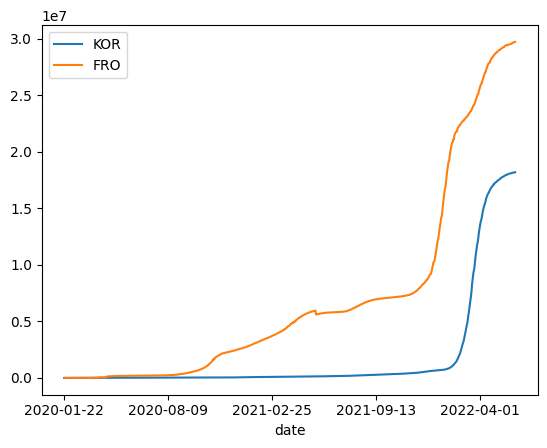

In [150]:
final_df.plot.line()

In [160]:
fr_population = fr_date_index_df['population']['2022-01-24']
fr_rate = round((fr_population/kor_population))

NameError: name 'fr_date_index_df' is not defined

In [152]:
# 인구 비율 구하기
# 미국 인구를 대한민국 인구로 나누어 비율을 확인

rate = round((fr_population/kor_population), 2)
rate

np.float64(1.31)

In [157]:
final_df2 = pd.DataFrame({'KOR':kor_total_case * })

KeyError: 'FRA'

<Axes: xlabel='date'>

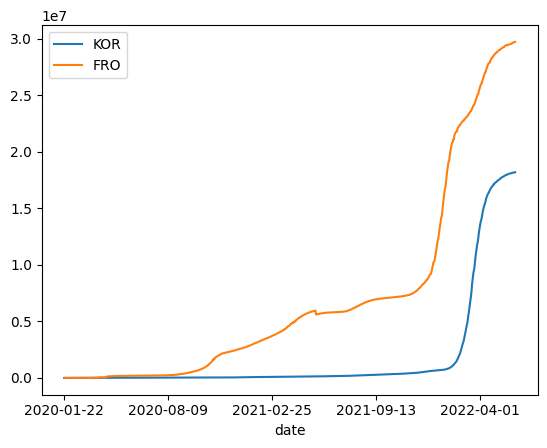

In [158]:
final_df.plot.line()

<Axes: xlabel='date'>

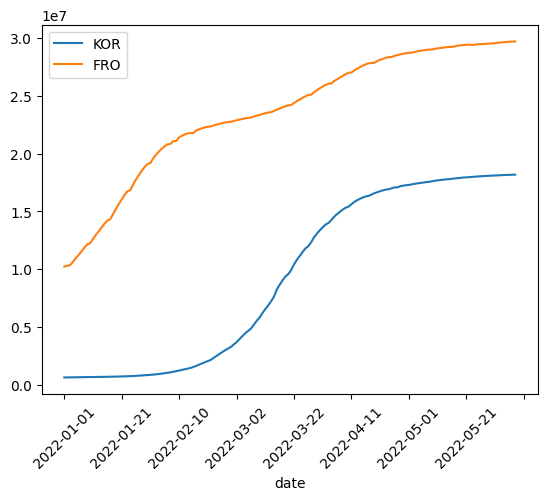

In [159]:
final_df['2022-01-01': ].plot.line(rot=45)